## Principal Component Analysis (PCA) for Dimensionality Reduction

### Imports and Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pickle

### Load Data

In [2]:
# Load data from dataset_generators/datasets
final_df_with_lags = pd.read_csv('../dataset_generators/datasets/final_1_lag_ffa_dataset.csv')

In [23]:
# Function to load the KFold PCA data
def load_kfold_pca_data(fold):
    train = pd.read_csv(f'../dataset_generators/datasets/{fold}_train_pca.csv')
    test = pd.read_csv(f'../dataset_generators/datasets/{fold}_test_pca.csv')
    return train, test

### XGBoost Model with PCA

In [ ]:
# Load the model and PCA transformer
with open('../model_generators/xgb/models/pca_xgb_model.pkl', 'rb') as f:
    xgb_pca_model = pickle.load(f)

with open('../model_generators/pca/models/pca_model.pkl', 'rb') as f:
    pca = pickle.load(f)

In [24]:
for fold in range(5):
    train, test = load_kfold_pca_data(fold)
    X_train_pca = train.iloc[:, 12:].drop(columns=['fantasy_points'])
    y_train = train['fantasy_points']
    X_test_pca = test.iloc[:, 12:].drop(columns=['fantasy_points'])
    y_test = test['fantasy_points']
    
# Concatenate all test sets
all_test = pd.concat([load_kfold_pca_data(fold)[1] for fold in range(5)], ignore_index=True)
# Remove duplicate rows where player_name, season, and week values are the same, keeping the first occurrence
all_test = all_test.drop_duplicates(subset=['player_name', 'season', 'week'], keep='first')
test = all_test
X_test_pca = test.iloc[:, 12:].drop(columns=['fantasy_points'])
y_test = test['fantasy_points']

# Concatenate all train sets
all_train = pd.concat([load_kfold_pca_data(fold)[0] for fold in range(5)], ignore_index=True)
# Remove duplicate rows where player_name, season, and week values are the same, keeping the first occurrence
all_train = all_train.drop_duplicates(subset=['player_name', 'season', 'week'], keep='first')
train = all_train
X_train_pca = train.iloc[:, 12:].drop(columns=['fantasy_points'])
y_train = train['fantasy_points']

In [58]:
# Function to extract PCA features
def extract_pca_features(pca):
    # export pca data to csv
    # pca_df = pd.DataFrame(pca.components_)
    # pca_df.to_csv('pca_components.csv', index=False)
    
    # Use the feature names from the original DataFrame columns
    feature_names = [col for col in final_df_with_lags.columns[11:] if col != 'fantasy_points']
    pca_columns = [f'PC{i+1}' for i in range(pca.n_components_)]
    pca_features = pd.DataFrame(pca.components_, columns=feature_names, index=pca_columns)
    return pca_features

pca_features = extract_pca_features(pca)

In [59]:
pca_features

,age,years_exp,passing_yards_r_avg_1_lag_1,passing_yards_r_avg_3_lag_1,passing_yards_r_avg_5_lag_1,passing_yards_r_avg_8_lag_1,passing_tds_r_avg_1_lag_1,passing_tds_r_avg_3_lag_1,passing_tds_r_avg_5_lag_1,passing_tds_r_avg_8_lag_1,...,fantasy_points_r_avg_5_lag_1,fantasy_points_r_avg_8_lag_1,opp_team_dst_fp_r_avg_1_lag_1,opp_team_dst_fp_r_avg_3_lag_1,opp_team_dst_fp_r_avg_5_lag_1,opp_team_dst_fp_r_avg_8_lag_1,opp_team_dst_fp_rank_r_avg_1_lag_1,opp_team_dst_fp_rank_r_avg_3_lag_1,opp_team_dst_fp_rank_r_avg_5_lag_1,opp_team_dst_fp_rank_r_avg_8_lag_1
PC1,0.061572,0.064572,0.243954,0.249289,0.249662,0.249371,0.213118,0.235714,0.239059,0.240048,...,0.187354,0.189033,0.000149,0.000678,-0.000186,-0.000326,-0.000866,-0.001082,-0.000233,-0.000014
PC2,-0.048560,-0.025976,-0.071601,-0.073975,-0.074417,-0.074639,-0.054718,-0.063122,-0.064955,-0.066224,...,0.216779,0.210308,0.018002,0.021909,0.022272,0.021451,-0.020619,-0.024298,-0.024336,-0.023252
PC3,0.073352,0.081951,0.060448,0.060909,0.060772,0.060638,0.062702,0.066465,0.066480,0.066340,...,0.120099,0.118340,-0.000986,0.000121,-0.000270,-0.000033,-0.000474,-0.001085,-0.000298,0.000126
PC4,-0.001713,-0.001356,-0.005628,-0.005987,-0.006098,-0.006178,-0.003521,-0.004181,-0.004470,-0.004703,...,0.012155,0.011554,-0.291537,-0.370956,-0.376988,-0.364639,0.291717,0.370793,0.377545,0.364514
PC5,-0.004327,-0.005498,-0.002000,-0.002197,-0.002149,-0.002130,-0.001858,-0.002336,-0.002559,-0.002687,...,0.001678,-0.000192,0.005256,0.002466,0.002351,0.002443,-0.007731,-0.005601,-0.005601,-0.005981
PC6,-0.005422,-0.007325,0.004647,0.005601,0.006161,0.006091,-0.003919,-0.000425,0.000028,0.000566,...,-0.031282,-0.027299,0.007227,0.004436,0.003205,0.002321,-0.003685,-0.002507,-0.001197,-0.000021
PC7,-0.000842,-0.002732,0.000432,-0.000021,-0.000341,-0.000241,-0.002891,-0.004901,-0.004385,-0.004225,...,-0.037970,-0.034869,0.003129,-0.002254,-0.001124,-0.000819,-0.006221,0.000572,0.000128,0.000355
PC8,-0.024552,-0.025187,-0.012166,-0.012735,-0.012396,-0.012752,-0.024952,-0.026054,-0.025868,-0.025411,...,-0.044417,-0.042139,0.003672,0.001684,0.002675,0.003779,-0.003615,-0.000873,-0.001846,-0.003012
PC9,-0.021722,-0.018269,-0.028683,-0.030206,-0.030112,-0.030006,-0.009997,-0.015415,-0.016741,-0.017960,...,-0.004465,-0.005615,0.002923,-0.000002,-0.000009,-0.000417,-0.005361,-0.003954,-0.004049,-0.003910
PC10,-0.191113,-0.191647,-0.076850,-0.074888,-0.073934,-0.073855,-0.125450,-0.124062,-0.122383,-0.118209,...,-0.043218,-0.044511,0.000990,0.000981,0.001656,0.000251,-0.000208,-0.000446,-0.001160,0.000234


In [60]:
# Find 3 max values for each principal component and format them nicely
max_contributing_features_df = pd.DataFrame()

for pc in pca_features.index:
    # Get absolute values and find top 4 features
    top_4_features = pca_features.loc[pc].abs().nlargest(4)
    
    # Create a series with feature names and their values
    feature_series = pd.Series({
        'PC': pc,
        'Top_1': f"{top_4_features.index[0]} ({top_4_features.values[0]:.3f})",
        'Top_2': f"{top_4_features.index[1]} ({top_4_features.values[1]:.3f})",
        'Top_3': f"{top_4_features.index[2]} ({top_4_features.values[2]:.3f})",
        'Top_4': f"{top_4_features.index[3]} ({top_4_features.values[3]:.3f})",
        'Explained_Variance_Ratio': f"{pca_features.loc[pc].abs().sum():.3f}"
    })
    
    max_contributing_features_df = pd.concat([max_contributing_features_df, feature_series.to_frame().T], ignore_index=True)

max_contributing_features_df.set_index('PC', inplace=True)
max_contributing_features_df


,Top_1,Top_2,Top_3,Top_4,Explained_Variance_Ratio
PC,,,,,
PC1,passing_yards_r_avg_5_lag_1 (0.250),passing_yards_r_avg_8_lag_1 (0.249),passing_yards_r_avg_3_lag_1 (0.249),passing_yards_r_avg_1_lag_1 (0.244),6.222
PC2,rushing_yards_r_avg_3_lag_1 (0.248),rushing_yards_r_avg_5_lag_1 (0.248),rushing_yards_r_avg_8_lag_1 (0.246),rushing_tds_r_avg_5_lag_1 (0.239),6.477
PC3,receiving_yards_r_avg_5_lag_1 (0.266),receiving_yards_r_avg_3_lag_1 (0.265),receiving_tds_r_avg_8_lag_1 (0.265),receiving_tds_r_avg_5_lag_1 (0.265),6.213
PC4,opp_team_dst_fp_rank_r_avg_5_lag_1 (0.378),opp_team_dst_fp_r_avg_5_lag_1 (0.377),opp_team_dst_fp_r_avg_3_lag_1 (0.371),opp_team_dst_fp_rank_r_avg_3_lag_1 (0.371),3.235
PC5,receiving_2pt_conversions_r_avg_5_lag_1 (0.441),receiving_2pt_conversions_r_avg_3_lag_1 (0.436),receiving_2pt_conversions_r_avg_8_lag_1 (0.428),receiving_2pt_conversions_r_avg_1_lag_1 (0.344),3.268
PC6,receiving_fumbles_lost_r_avg_5_lag_1 (0.350),receiving_fumbles_lost_r_avg_3_lag_1 (0.344),receiving_fumbles_lost_r_avg_8_lag_1 (0.340),receiving_fumbles_lost_r_avg_1_lag_1 (0.271),4.594
PC7,rushing_2pt_conversions_r_avg_5_lag_1 (0.405),rushing_2pt_conversions_r_avg_3_lag_1 (0.401),rushing_2pt_conversions_r_avg_8_lag_1 (0.393),rushing_2pt_conversions_r_avg_1_lag_1 (0.315),4.503
PC8,rushing_fumbles_lost_r_avg_3_lag_1 (0.450),rushing_fumbles_lost_r_avg_5_lag_1 (0.447),rushing_fumbles_lost_r_avg_8_lag_1 (0.432),rushing_fumbles_lost_r_avg_1_lag_1 (0.369),4.677
PC9,passing_2pt_conversions_r_avg_3_lag_1 (0.478),passing_2pt_conversions_r_avg_5_lag_1 (0.472),passing_2pt_conversions_r_avg_8_lag_1 (0.455),passing_2pt_conversions_r_avg_1_lag_1 (0.399),3.303


In [61]:
# Function to rename index to reflect top contributing feature
def rename_pca_index(max_contributing_features_df, pca_features):
    # Create a mapping of old index to new index based on the top contributing feature
    index_mapping = {}
    used_names = set()

    for pc in max_contributing_features_df.index:
        # Loop through all top contributing features for the principal component
        for rank in ['Top_1', 'Top_2', 'Top_3', 'Top_4']:
            top_feature = max_contributing_features_df.loc[pc, rank].split(' ')[0]
            if top_feature not in used_names:
                used_names.add(top_feature)
                new_name = f"PC_{top_feature}"
                # Be sure to remove last 14 characters from each entry here except 'age' and 'years_exp' before checking uniqueness
                if new_name.endswith('_age') or new_name.endswith('_years_exp'):
                    pass
                else:
                    new_name = new_name[:-14]
                index_mapping[pc] = new_name
                break

    # Rename the index using the mapping
    max_contributing_features_df.rename(index=index_mapping, inplace=True)
    
    # Simply add number suffixes to duplicates
    final_index = []
    name_count = {}

    for name in max_contributing_features_df.index:
        if name in name_count:
            name_count[name] += 1
            new_name = f"{name}_{name_count[name]}"
            final_index.append(new_name)
        else:
            name_count[name] = 1
            final_index.append(name)

    max_contributing_features_df.index = final_index

    return max_contributing_features_df

# Apply the function to rename the index
renamed_pca_features = rename_pca_index(max_contributing_features_df, pca_features)
renamed_pca_features

,Top_1,Top_2,Top_3,Top_4,Explained_Variance_Ratio
PC_passing_yards,passing_yards_r_avg_5_lag_1 (0.250),passing_yards_r_avg_8_lag_1 (0.249),passing_yards_r_avg_3_lag_1 (0.249),passing_yards_r_avg_1_lag_1 (0.244),6.222
PC_rushing_yards,rushing_yards_r_avg_3_lag_1 (0.248),rushing_yards_r_avg_5_lag_1 (0.248),rushing_yards_r_avg_8_lag_1 (0.246),rushing_tds_r_avg_5_lag_1 (0.239),6.477
PC_receiving_yards,receiving_yards_r_avg_5_lag_1 (0.266),receiving_yards_r_avg_3_lag_1 (0.265),receiving_tds_r_avg_8_lag_1 (0.265),receiving_tds_r_avg_5_lag_1 (0.265),6.213
PC_opp_team_dst_fp_rank,opp_team_dst_fp_rank_r_avg_5_lag_1 (0.378),opp_team_dst_fp_r_avg_5_lag_1 (0.377),opp_team_dst_fp_r_avg_3_lag_1 (0.371),opp_team_dst_fp_rank_r_avg_3_lag_1 (0.371),3.235
PC_receiving_2pt_conversions,receiving_2pt_conversions_r_avg_5_lag_1 (0.441),receiving_2pt_conversions_r_avg_3_lag_1 (0.436),receiving_2pt_conversions_r_avg_8_lag_1 (0.428),receiving_2pt_conversions_r_avg_1_lag_1 (0.344),3.268
PC_receiving_fumbles_lost,receiving_fumbles_lost_r_avg_5_lag_1 (0.350),receiving_fumbles_lost_r_avg_3_lag_1 (0.344),receiving_fumbles_lost_r_avg_8_lag_1 (0.340),receiving_fumbles_lost_r_avg_1_lag_1 (0.271),4.594
PC_rushing_2pt_conversions,rushing_2pt_conversions_r_avg_5_lag_1 (0.405),rushing_2pt_conversions_r_avg_3_lag_1 (0.401),rushing_2pt_conversions_r_avg_8_lag_1 (0.393),rushing_2pt_conversions_r_avg_1_lag_1 (0.315),4.503
PC_rushing_fumbles_lost,rushing_fumbles_lost_r_avg_3_lag_1 (0.450),rushing_fumbles_lost_r_avg_5_lag_1 (0.447),rushing_fumbles_lost_r_avg_8_lag_1 (0.432),rushing_fumbles_lost_r_avg_1_lag_1 (0.369),4.677
PC_passing_2pt_conversions,passing_2pt_conversions_r_avg_3_lag_1 (0.478),passing_2pt_conversions_r_avg_5_lag_1 (0.472),passing_2pt_conversions_r_avg_8_lag_1 (0.455),passing_2pt_conversions_r_avg_1_lag_1 (0.399),3.303
PC_sack_fumbles_lost,sack_fumbles_lost_r_avg_3_lag_1 (0.439),sack_fumbles_lost_r_avg_5_lag_1 (0.423),sack_fumbles_lost_r_avg_8_lag_1 (0.402),sack_fumbles_lost_r_avg_1_lag_1 (0.393),4.756


### XGBoost w/ PCA Data Visualizations

<Figure size 1000x800 with 0 Axes>

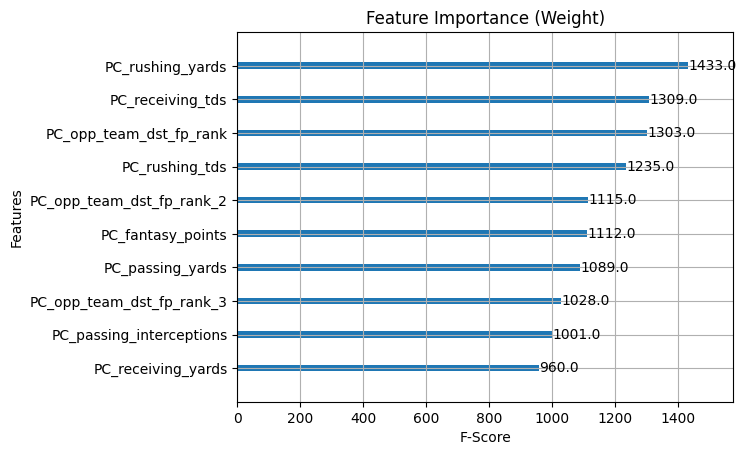

<Figure size 1000x800 with 0 Axes>

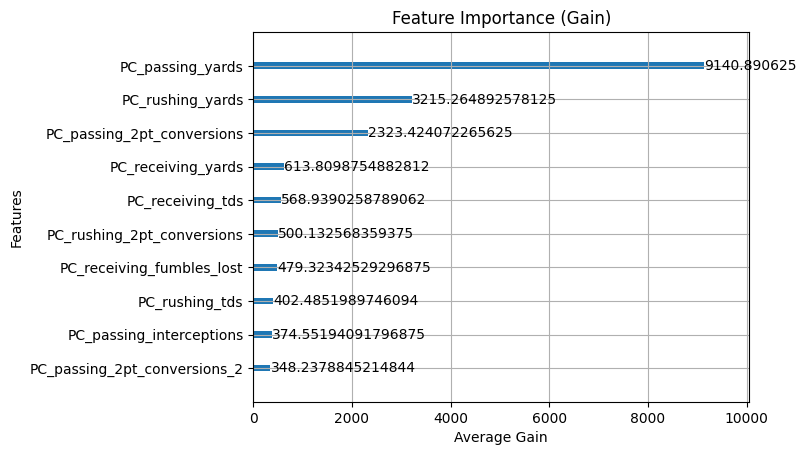

In [63]:
# Use the trained model to plot feature importance
import matplotlib.pyplot as plt
import xgboost as xgb

def plot_feature_importance(model, feature_names):
    feature_names = feature_names.tolist() if isinstance(feature_names, pd.Index) else feature_names
    model.get_booster().feature_names = feature_names
    plt.figure(figsize=(10, 8))
    xgb.plot_importance(model, importance_type='weight', max_num_features=10, xlabel='F-Score', )
    plt.title("Feature Importance (Weight)")
    plt.show()
    plt.figure(figsize=(10, 8))
    xgb.plot_importance(model, importance_type='gain', max_num_features=10, xlabel='Average Gain')
    plt.title("Feature Importance (Gain)")
    plt.show()

feature_names = renamed_pca_features.index.tolist() if isinstance(renamed_pca_features.index, pd.Index) else renamed_pca_features.index
# Use the correct feature names for the model
plot_feature_importance(xgb_pca_model, feature_names)

c:\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|===================| 59446/59498 [14:26<00:00]        

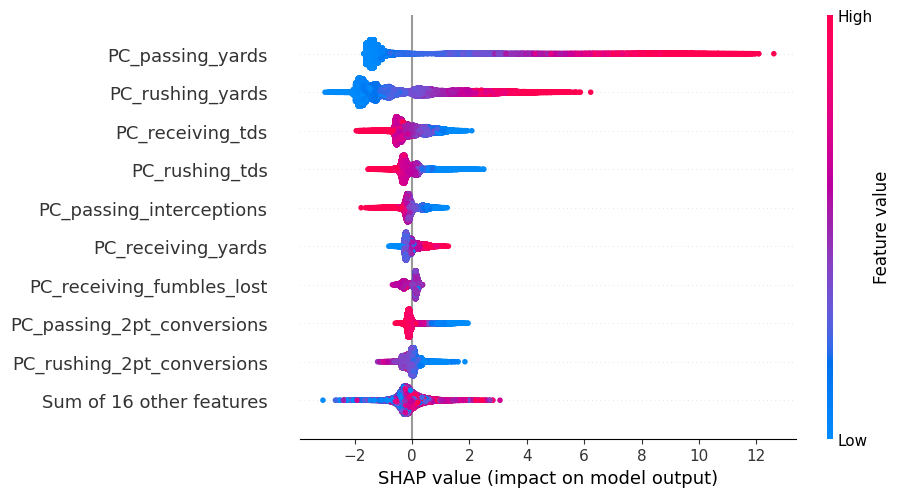

<Figure size 640x480 with 0 Axes>

In [ ]:
# Function to use SHAP to explain the machine learning model behavior with SHAP beeswarm plot
import shap

def plot_shap_beeswarm(model, X_test_pca, renamed_pca_features):
    # Original feature names in X_test_pca
    original_feature_names = [f"PC{i+1}" for i in range(X_test_pca.shape[1])]
    
    # Create a mapping from original feature names to renamed PCA feature names
    feature_name_mapping = dict(zip(original_feature_names, renamed_pca_features.index))
    
    # Convert X_test_pca to DataFrame with renamed PCA feature names as columns
    X_test_pca_df = pd.DataFrame(X_test_pca, columns=original_feature_names)
    X_test_pca_df.rename(columns=feature_name_mapping, inplace=True)
    
    # Create explainer and calculate SHAP values
    explainer = shap.Explainer(model, X_test_pca_df)
    shap_values = explainer(X_test_pca_df)
    
    # Plot beeswarm and save figure
    plt.figure(figsize=(10, 6))
    shap.plots.beeswarm(shap_values)
    plt.savefig("../model_visualizations/pca/shap_beeswarm.png")
    plt.tight_layout()

# Use the corrected function
plot_shap_beeswarm(xgb_pca_model, X_test_pca, renamed_pca_features)

In [ ]:
# Function to use model to predict fantasy points for all weeks
def predict_fantasy_points(model):
    """
    Predict fantasy points for each player's next game using the trained model.
    
    Args:
        model: Trained XGBoost model
        
    Returns:
        DataFrame: Predicted fantasy points with player info
    """
    
    # Concatenate all test sets
    all_test = pd.concat([load_kfold_pca_data(fold)[1] for fold in range(5)], ignore_index=True)
    
    # Use renamed PCA feature names for the columns
    X_test_pca = all_test.iloc[:, 12:].drop(columns=['fantasy_points'])
    X_test_pca.columns = renamed_pca_features.index  # Rename columns to match renamed PCA features
    
    # Ensure X_test_pca is a 2D array
    X_test_pca = X_test_pca.values
    
    # Make predictions using the PCA-transformed data
    predicted_fantasy_points = model.predict(X_test_pca)

    all_test['predicted_fantasy_points'] = predicted_fantasy_points

    return all_test[['player_id', 'player_name', 'position_group', 'team', 'season', 'week', 'fantasy_points', 'predicted_fantasy_points']]

# Predict fantasy points using the last trained model and PCA
predicted_fantasy_points = predict_fantasy_points(xgb_pca_model)
predicted_fantasy_points

,player_id,player_name,position_group,team,season,week,fantasy_points,predicted_fantasy_points
0,00-0007091,M.Hasselbeck,QB,IND,2015,5,16.22,15.456262
1,00-0007091,M.Hasselbeck,QB,IND,2015,12,20.30,14.933200
2,00-0007091,M.Hasselbeck,QB,IND,2015,13,4.86,17.059111
3,00-0010346,P.Manning,QB,DEN,2015,8,11.60,12.651504
4,00-0010346,P.Manning,QB,DEN,2015,10,-6.60,9.692089
...,...,...,...,...,...,...,...,...
60964,00-0039919,R.Odunze,WR,CHI,2024,6,4.00,6.898281
60965,00-0039919,R.Odunze,WR,CHI,2024,8,5.40,4.894446
60966,00-0039919,R.Odunze,WR,CHI,2024,13,2.50,5.582048
60967,00-0039919,R.Odunze,WR,CHI,2024,14,16.20,6.756597


In [19]:
# Remove duplicate rows where player_name, season, and week values are the same, keeping the first occurrence
predicted_fantasy_points = predicted_fantasy_points.drop_duplicates(subset=['player_name', 'season', 'week'], keep='first')

# Show the cleaned DataFrame
predicted_fantasy_points

,player_id,player_name,position_group,team,season,week,fantasy_points,predicted_fantasy_points
0,00-0007091,M.Hasselbeck,QB,IND,2015,5,16.22,15.456262
1,00-0007091,M.Hasselbeck,QB,IND,2015,12,20.30,14.933200
2,00-0007091,M.Hasselbeck,QB,IND,2015,13,4.86,17.059111
3,00-0010346,P.Manning,QB,DEN,2015,8,11.60,12.651504
4,00-0010346,P.Manning,QB,DEN,2015,10,-6.60,9.692089
...,...,...,...,...,...,...,...,...
60964,00-0039919,R.Odunze,WR,CHI,2024,6,4.00,6.898281
60965,00-0039919,R.Odunze,WR,CHI,2024,8,5.40,4.894446
60966,00-0039919,R.Odunze,WR,CHI,2024,13,2.50,5.582048
60967,00-0039919,R.Odunze,WR,CHI,2024,14,16.20,6.756597


In [20]:
# Save the predictions to a CSV file
predicted_fantasy_points.to_csv('../predictions/xgb_pca_predictions.csv', index=False)

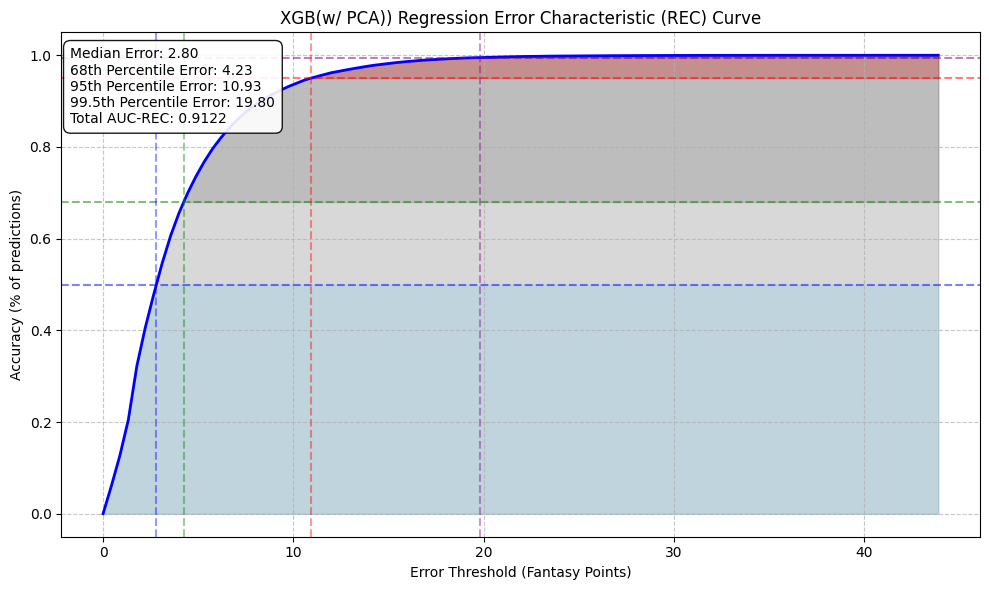

99.5th Percentile Error: 19.80 fantasy points
95th Percentile Error: 10.93 fantasy points
68th Percentile Error: 4.23 fantasy points
Median Error: 2.80 fantasy points
Total AUC-REC: 0.9122


In [ ]:
# Function for Regression Error Characteristic (REC) Curves
def plot_rec_curve(predicted_fantasy_points):
    predicted_fantasy_points = predicted_fantasy_points.copy()
    
    # Calculate the absolute errors
    predicted_fantasy_points['absolute_error'] = predicted_fantasy_points['predicted_fantasy_points'] - predicted_fantasy_points['fantasy_points']
    predicted_fantasy_points['absolute_error'] = predicted_fantasy_points['absolute_error'].abs()
    
    # Calculate absolute errors
    errors = predicted_fantasy_points['absolute_error'].values
    
    # Create threshold values from 0 to max error
    thresholds = np.linspace(0, max(errors), 100)
    
    # Calculate accuracy for each threshold
    accuracies = [np.mean(errors <= threshold) for threshold in thresholds]
    
    # Plot REC curve
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, accuracies, 'b-', linewidth=2)
    plt.xlabel('Error Threshold (Fantasy Points)')
    plt.ylabel('Accuracy (% of predictions)')
    plt.title('XGB(w/ PCA)) Regression Error Characteristic (REC) Curve')
    
    # Fill area under the curve
    plt.fill_between(thresholds, np.zeros_like(thresholds), accuracies, alpha=0.3, color='grey')
    
    # Fill 99.5th Percentile Error with different color
    percentile_99_5 = np.percentile(errors, 99.5)
    accuracy_99_5 = np.mean(errors <= percentile_99_5)
    plt.axvline(x=percentile_99_5, color='purple', linestyle='--', label=f'99.5th Percentile Error: {percentile_99_5:.2f}', alpha=0.4)
    plt.axhline(y=accuracy_99_5, color='purple', linestyle='--', label=f'99.5th Percentile Accuracy: {accuracy_99_5:.2f}', alpha=0.5)
    # Shaded region under the curve ONLY at 99.5th percentile (99.5% and above)
    plt.fill_between(thresholds, accuracy_99_5, accuracies, where=(thresholds >= percentile_99_5), color='purple', alpha=0.3, label='99.5% Accuracy Region')
    
    # Fill 95th Percentile Error with different color
    percentile_95 = np.percentile(errors, 95)
    accuracy_95 = np.mean(errors <= percentile_95)
    plt.axvline(x=percentile_95, color='red', linestyle='--', label=f'95th Percentile Error: {percentile_95:.2f}', alpha=0.4)
    plt.axhline(y=accuracy_95, color='red', linestyle='--', label=f'95th Percentile Accuracy: {accuracy_95:.2f}', alpha=0.5)
    # Shaded region under the curve ONLY at 95th percentile (95% and above)
    plt.fill_between(thresholds, accuracy_95, accuracies, where=(thresholds >= percentile_95), color='red', alpha=0.3, label='95% Accuracy Region')

    # Fill 68th Percentile Error with different color
    percentile_68 = np.percentile(errors, 68)
    accuracy_68 = np.mean(errors <= percentile_68)
    plt.axvline(x=percentile_68, color='green', linestyle='--', label=f'68th Percentile Error: {percentile_68:.2f}', alpha=0.4)
    plt.axhline(y=accuracy_68, color='green', linestyle='--', label=f'68th Percentile Accuracy: {accuracy_68:.2f}', alpha=0.5)
    # Shaded region under the curve ONLY at 68th percentile (68% and above)
    plt.fill_between(thresholds, accuracy_68, accuracies, where=(thresholds >= percentile_68), color='grey', alpha=0.3, label='68% Accuracy Region')

    # Add grid
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Add reference line at median error
    median_error = np.median(errors)
    plt.axhline(y=0.5, color='blue', linestyle='--', alpha=0.5)
    plt.axvline(x=median_error, color='blue', linestyle='--', label=f'Median Error: {median_error:.2f}', alpha=0.4)
    
    # Shaded region under the curve at median error (50% and below)
    plt.fill_between(thresholds, 0, np.minimum(accuracies, 0.5), color='skyblue', alpha=0.3, label='50% Accuracy Region')
    
    # Calculate total area under the REC curve (AUC-REC)
    auc_rec = np.trapz(accuracies, thresholds) / (max(thresholds) * 1)  # Normalize by max threshold

    # Add box to upper left corner with statistics
    stats_text = f'Median Error: {median_error:.2f}\n68th Percentile Error: {percentile_68:.2f}\n95th Percentile Error: {percentile_95:.2f}\n99.5th Percentile Error: {percentile_99_5:.2f}\nTotal AUC-REC: {auc_rec:.4f}'
    plt.gca().text(0.01, 0.97, stats_text, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9))

    # Improve layout
    plt.tight_layout()
    # plt.savefig('rec_curve.png')
    plt.show()
    plt.close()
    
    # Print some statistics
    print(f"99.5th Percentile Error: {percentile_99_5:.2f} fantasy points")
    print(f"95th Percentile Error: {percentile_95:.2f} fantasy points")
    print(f"68th Percentile Error: {percentile_68:.2f} fantasy points")
    print(f"Median Error: {median_error:.2f} fantasy points")
    print(f"Total AUC-REC: {auc_rec:.4f}")
    
plot_rec_curve(predicted_fantasy_points)